## ARIMA

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = (20,5)


<Axes: title={'center': 'White Noise process'}, xlabel='Time'>

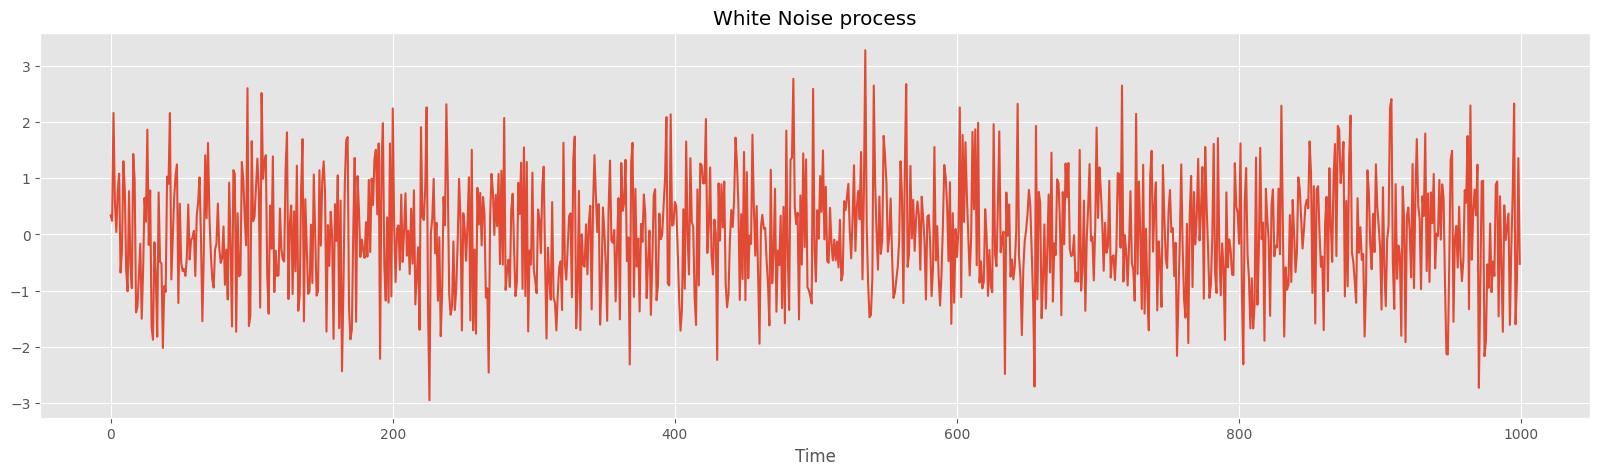

In [89]:
n_obs = 1000
sample = pd.Series(np.random.normal(size=n_obs))

plt.title('White Noise process')
plt.xlabel('Time')
sample.plot()

##### MA-процесс

Попробуем посимулировать и взглянуть на различные MA-процессы.

In [90]:
from statsmodels.api import tsa

Начнём с процесса белого шума, или MA(0):

$$y_t = \mu + \epsilon_t, \ \epsilon_t \sim iid N(0, 1)$$

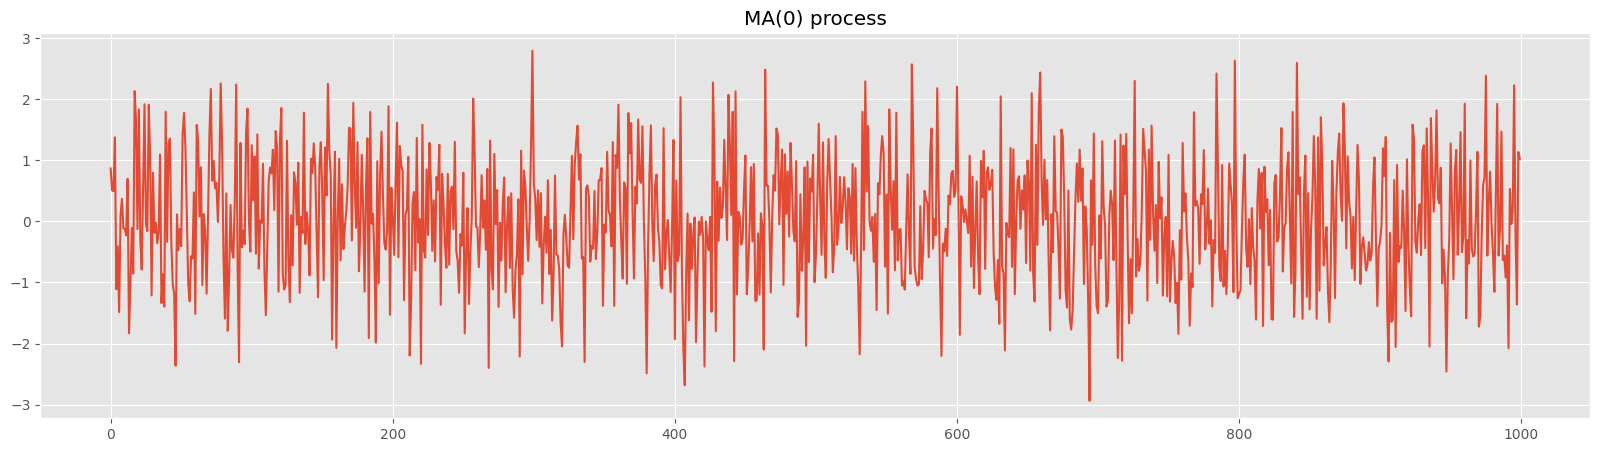

In [91]:
wn_process = tsa.ArmaProcess()
sample = pd.Series(wn_process.generate_sample(nsample=n_obs, burnin = 1000))
sample.plot()
plt.title('MA(0) process');

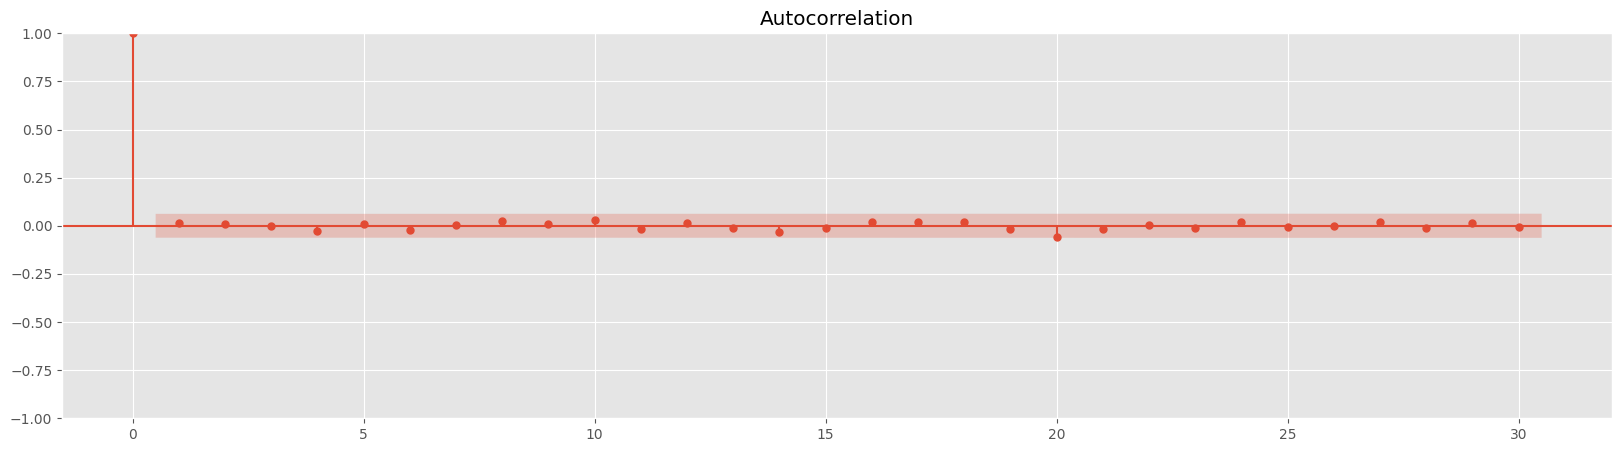

In [92]:
plot_acf(sample);

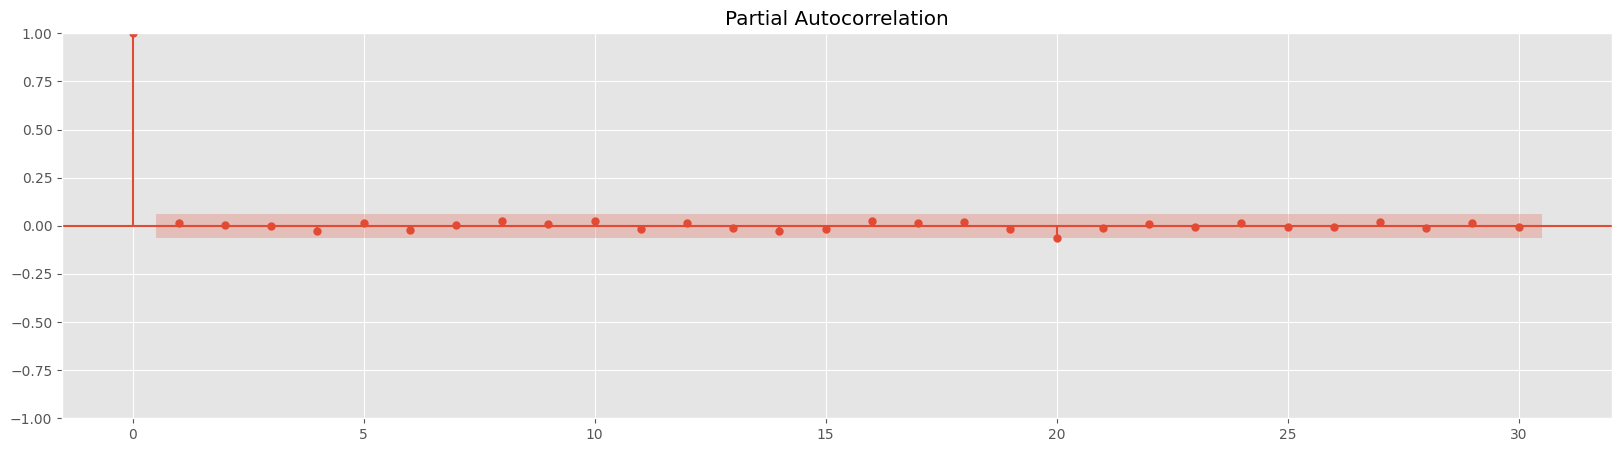

In [93]:
plot_pacf(sample);

Теперь MA(1):

$$y_t = \mu + \epsilon_t + 0.9 \epsilon_{t-1}, \ \epsilon_t \sim iid N(0, 1)$$

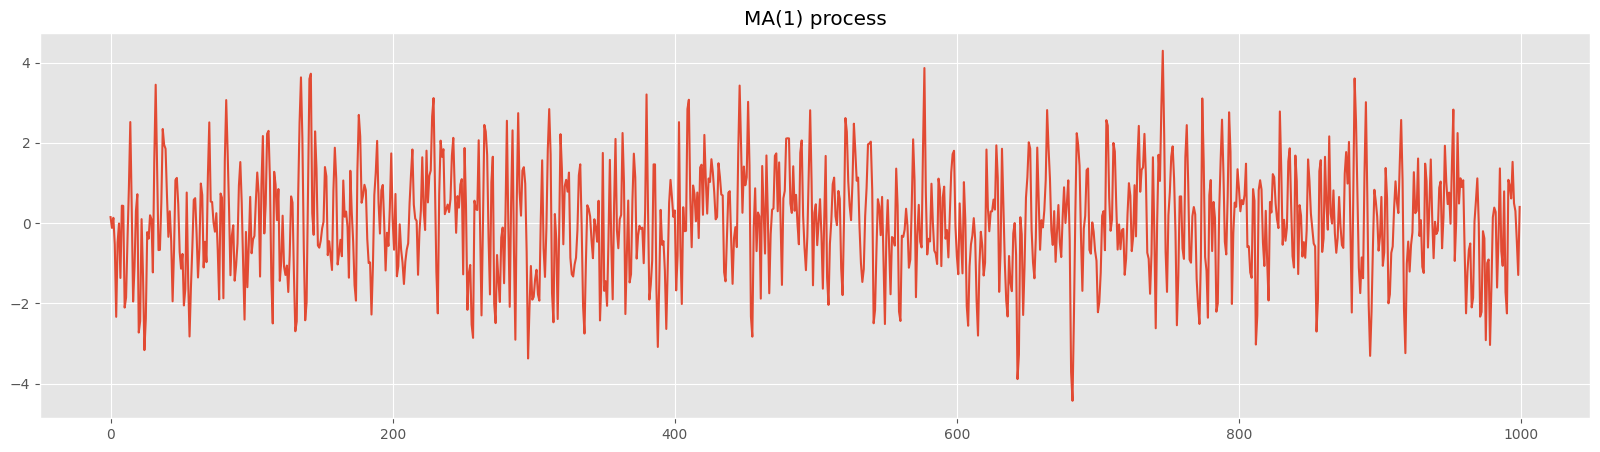

In [94]:
ma_process = tsa.ArmaProcess(ma=[1, 0.9])
sample = pd.Series(ma_process.generate_sample(nsample=n_obs, burnin = 10000))
sample.plot()
plt.title('MA(1) process');

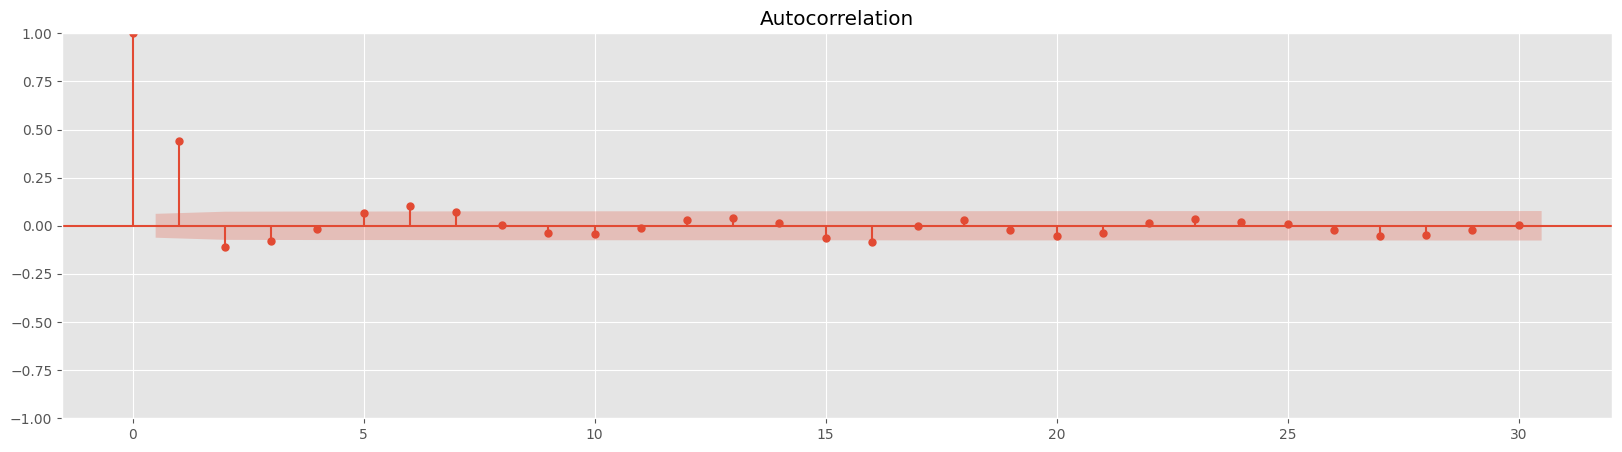

In [95]:
plot_acf(sample);


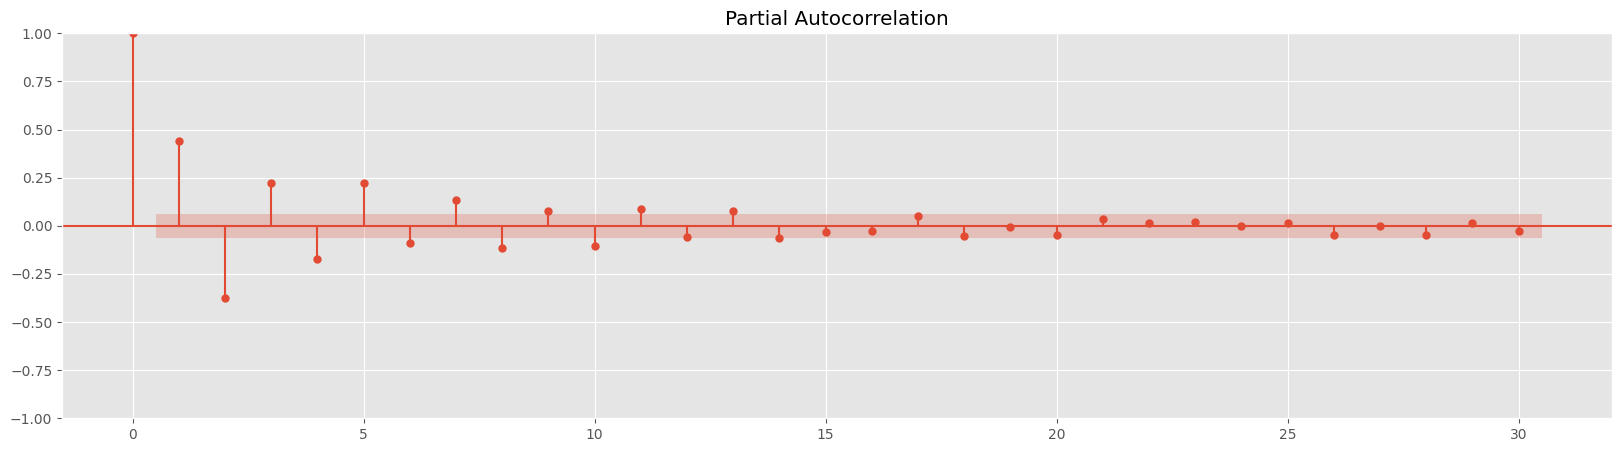

In [96]:
plot_pacf(sample);

MA(5):

$$y_t = \mu + \epsilon_t + 0.9 \epsilon_{t-1} + 0.8 \epsilon_{t-2} + 0.5 \epsilon_{t-3} + 0.6 \epsilon_{t-4} + 0.2 \epsilon_{t-5}, \ \epsilon_t \sim iid N(0, 1)$$

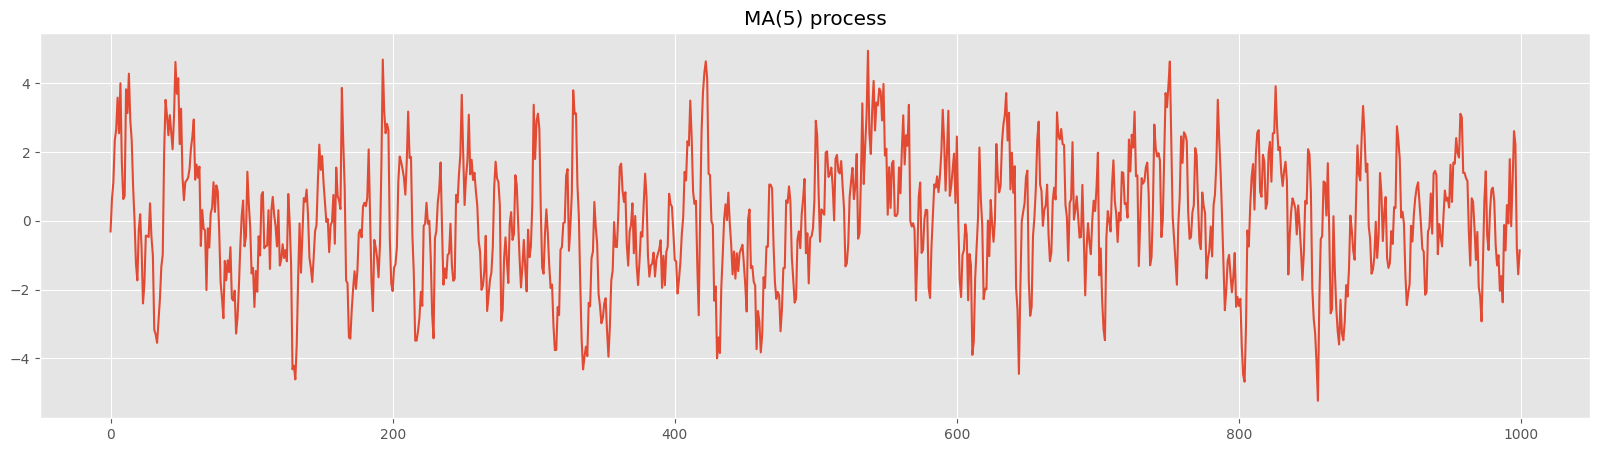

In [97]:
ma_process = tsa.ArmaProcess(ma=[1, 0.9, 0.8, 0.5, 0.6, 0.2])
sample = pd.Series(ma_process.generate_sample(nsample=n_obs, burnin = 1000))
sample.plot()
plt.title('MA(5) process');

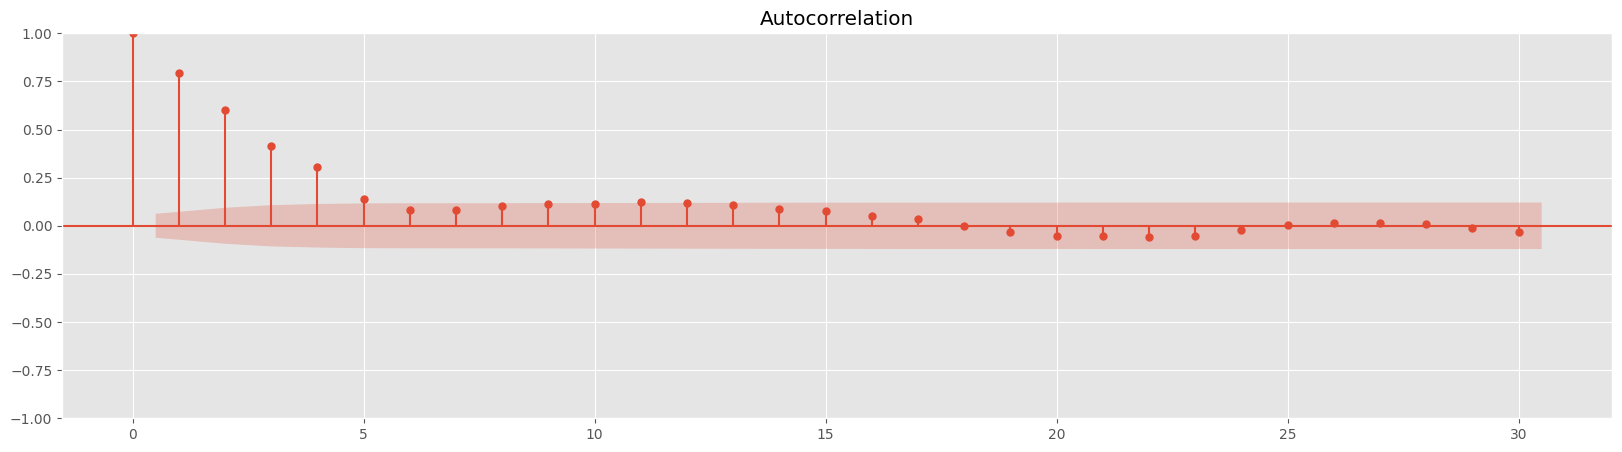

In [98]:
plot_acf(sample);

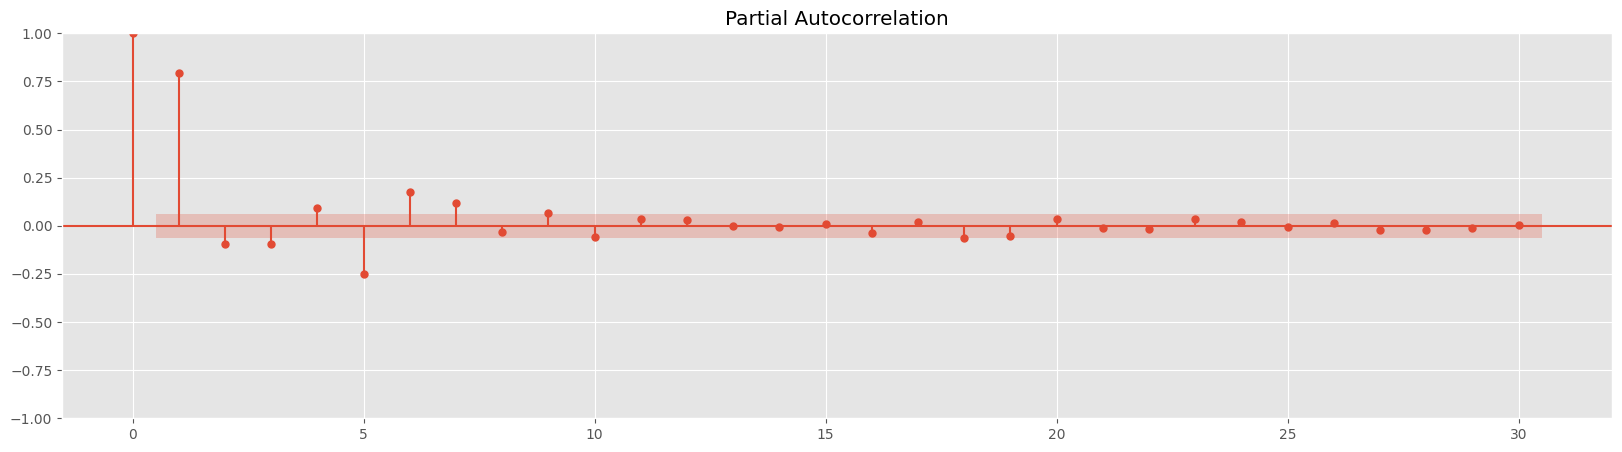

In [99]:
plot_pacf(sample);

In [100]:
import matplotlib.pyplot as plt
import pandas as pd

from statsmodels.api import tsa



plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = (20,5)

### AR(p)-процесс

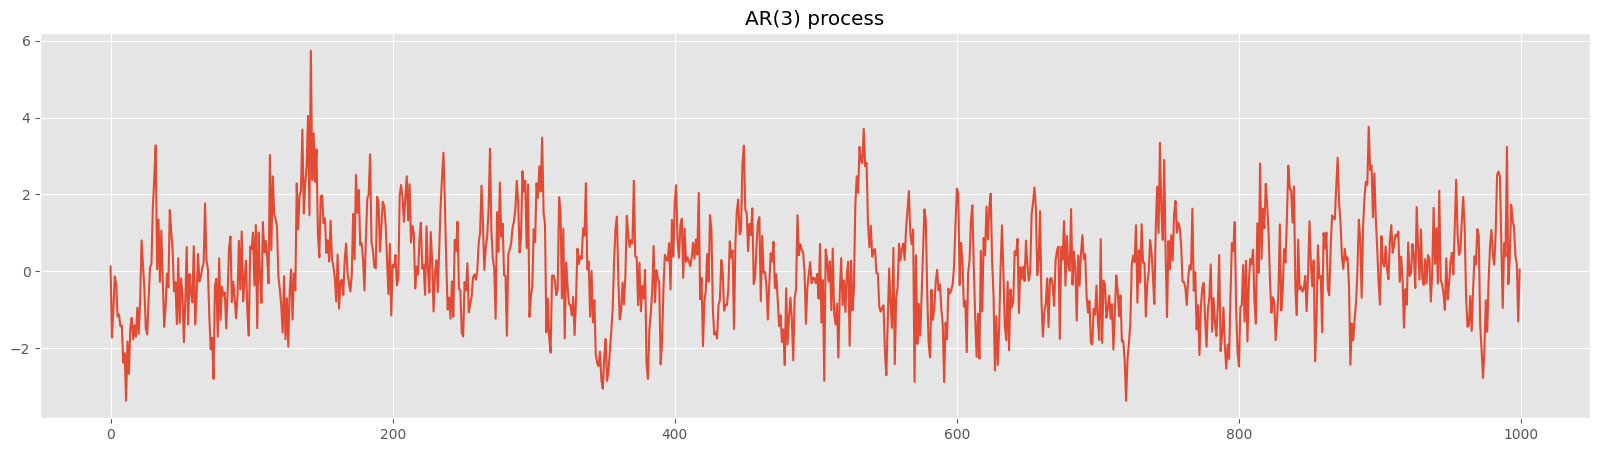

In [101]:
ma_process = tsa.ArmaProcess(ar=[1, -0.5, -0.25])
sample = pd.Series(ma_process.generate_sample(nsample=1000, burnin = 10000))
sample.plot()
plt.title('AR(3) process');

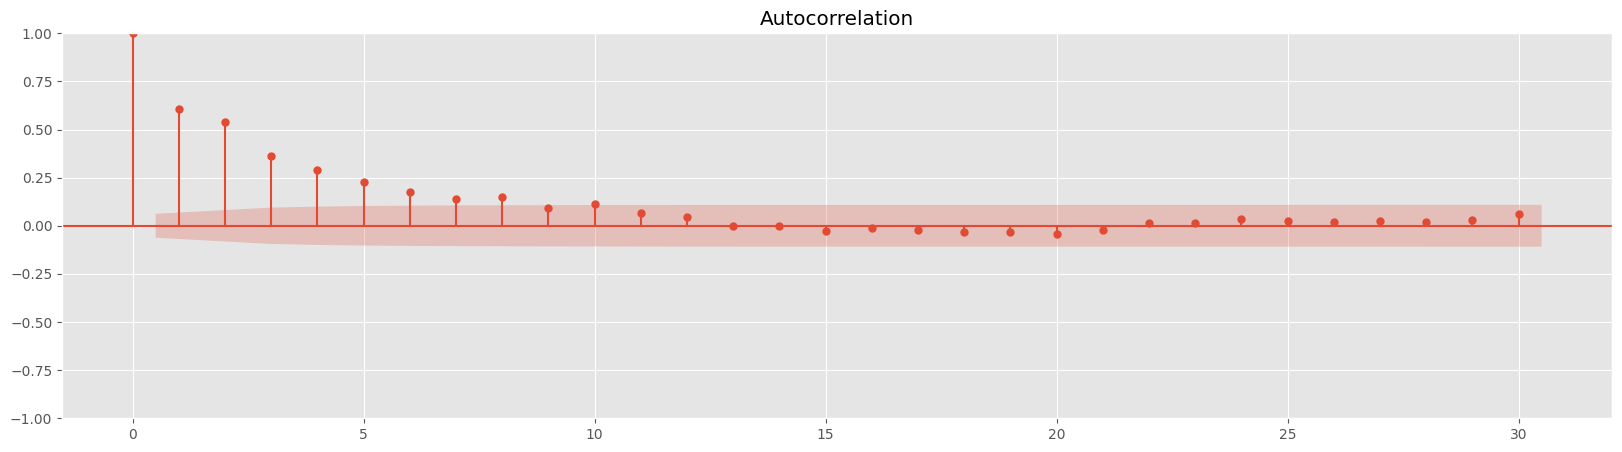

In [102]:
plot_acf(sample);

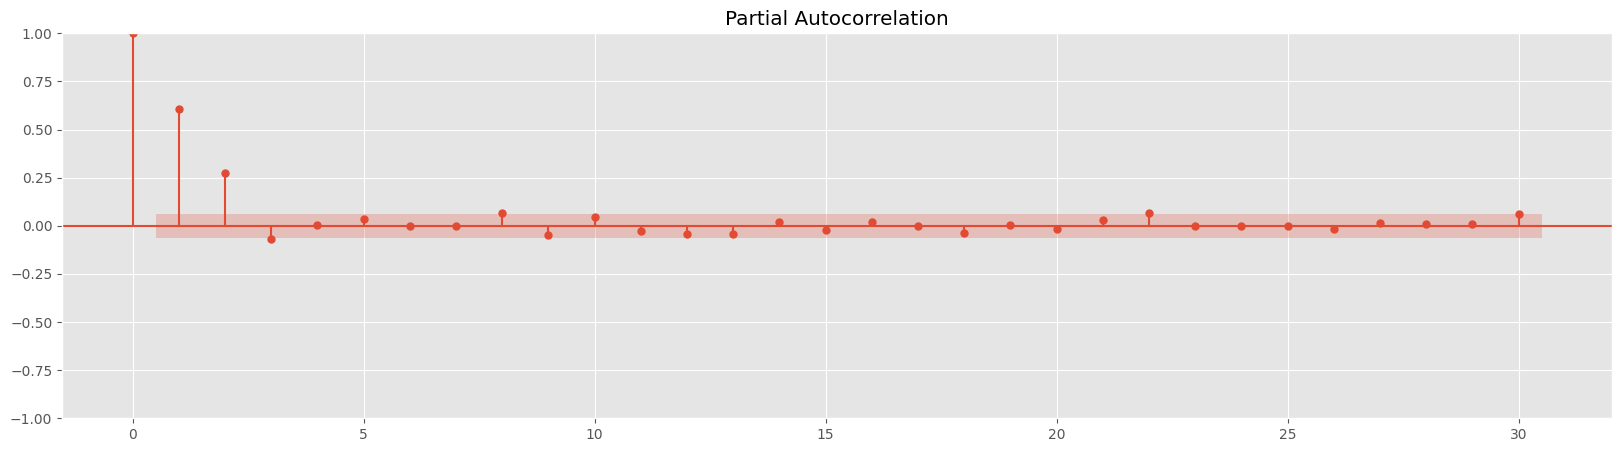

In [103]:
plot_pacf(sample);

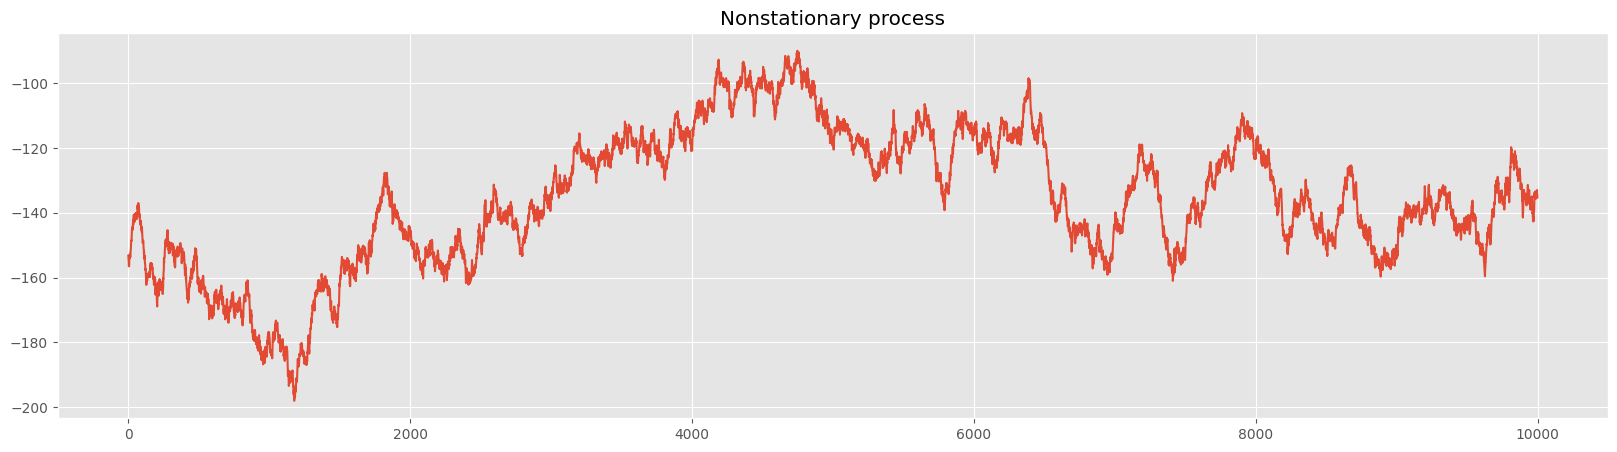

In [104]:
nonstationary_process = tsa.ArmaProcess(ar=[1, -1])
sample = pd.Series(nonstationary_process.generate_sample(nsample=10000, burnin = 10000))
sample.plot()
plt.title('Nonstationary process');


In [105]:
nonstationary_process.isstationary

False

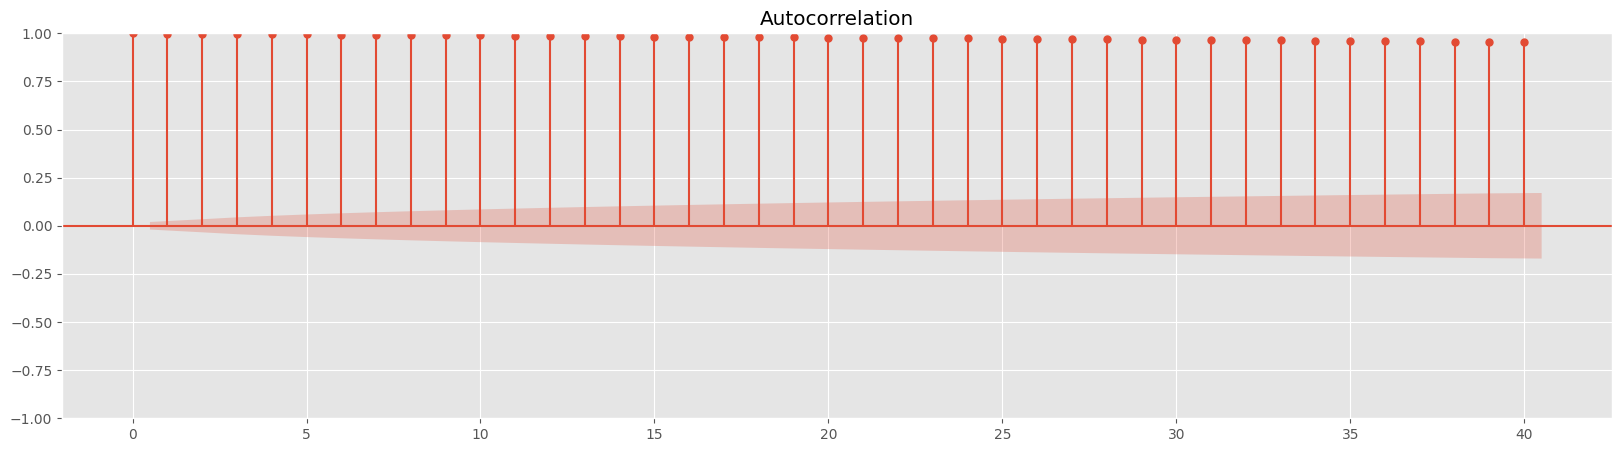

In [106]:
plot_acf(sample);

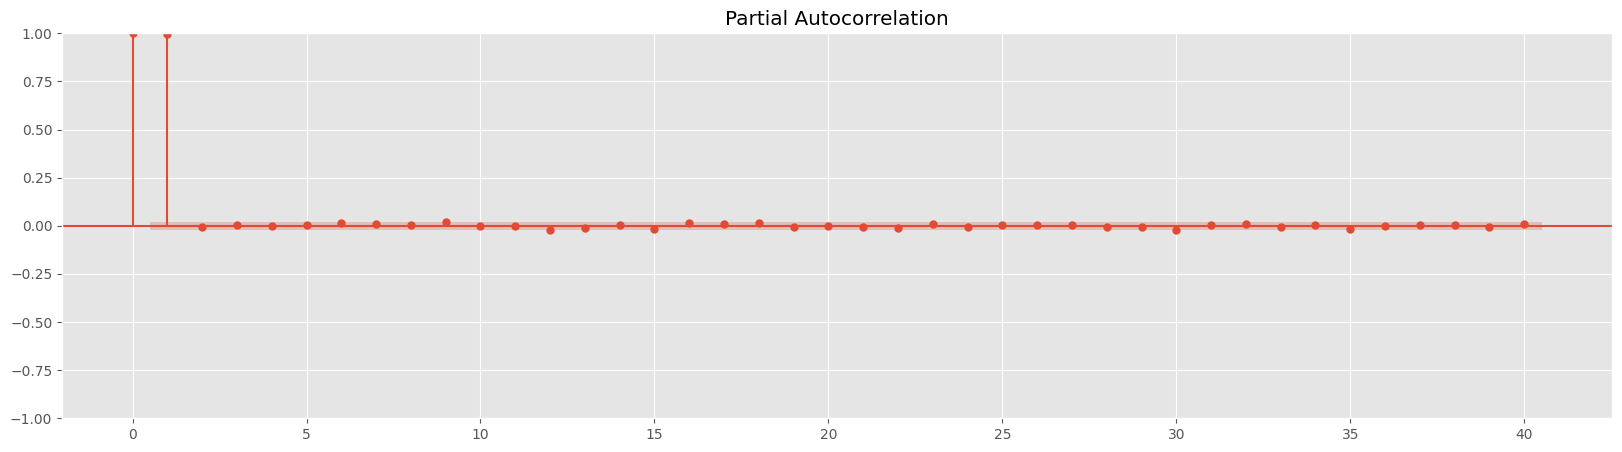

In [107]:
plot_pacf(sample);

### Примеры нестационарных рядов

In [108]:
beta_0 = 1
beta_1 = 0.5
sigma_sq = 16
n_steps = 1000

# Ряд с детерминированным трендом
y_det = [beta_0 + beta_1 * t + np.random.normal(scale=sigma_sq) for t in range(n_steps)]

# Ряд со стохастическим трендом
y_stoch = [0]
[y_stoch.append(beta_0 + y_stoch[-1] + np.random.normal(scale=sigma_sq)) for t in range(n_steps)]

y_det = pd.Series(y_det)
y_stoch = pd.Series(y_stoch)

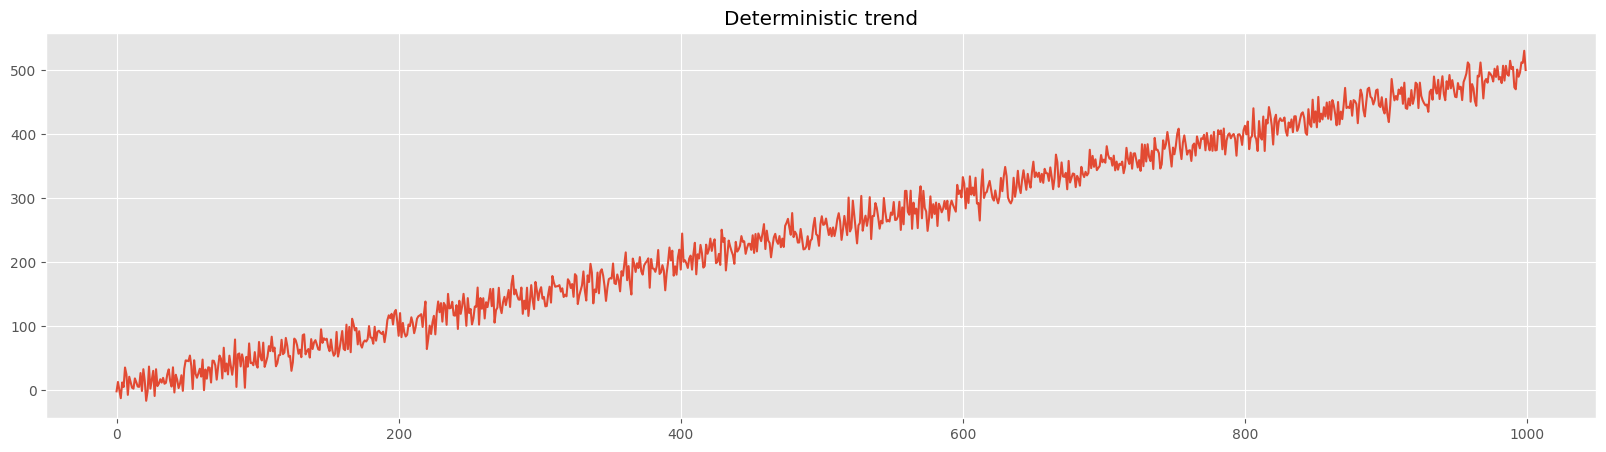

In [109]:
y_det.plot()
plt.title("Deterministic trend");

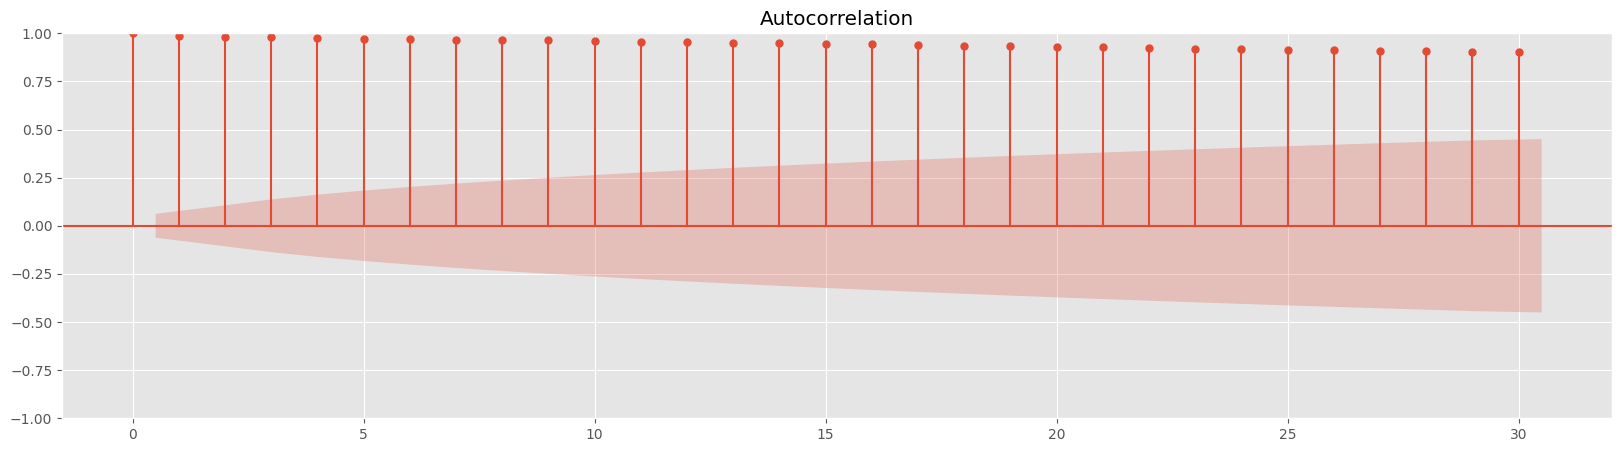

In [110]:
plot_acf(y_det);

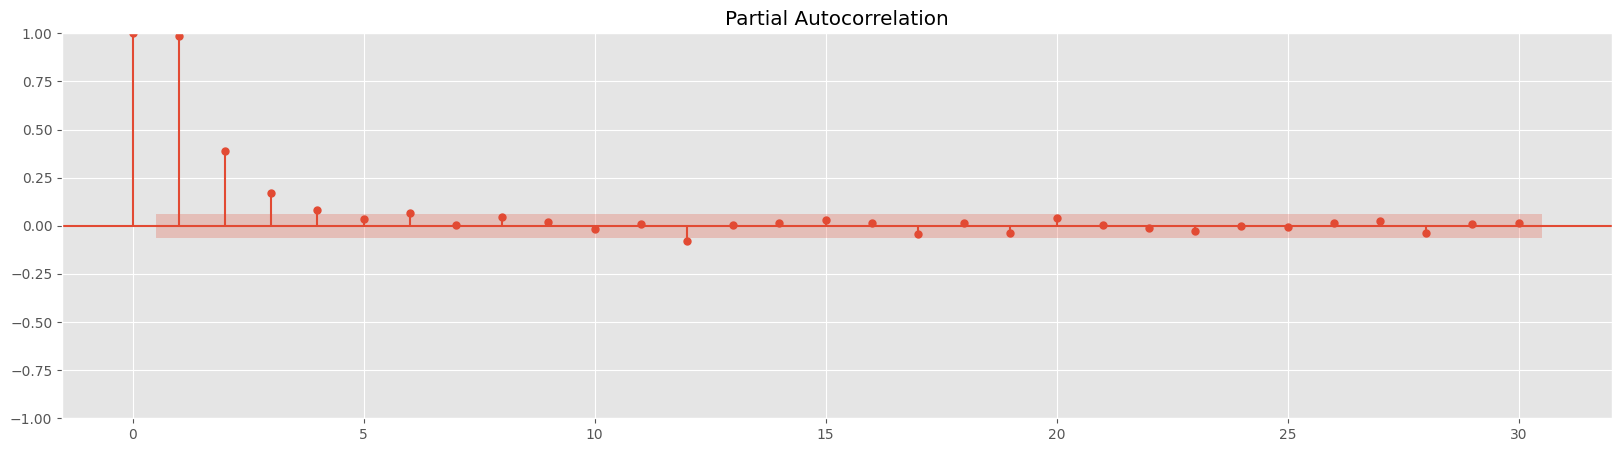

In [111]:
plot_pacf(y_det);

<Axes: >

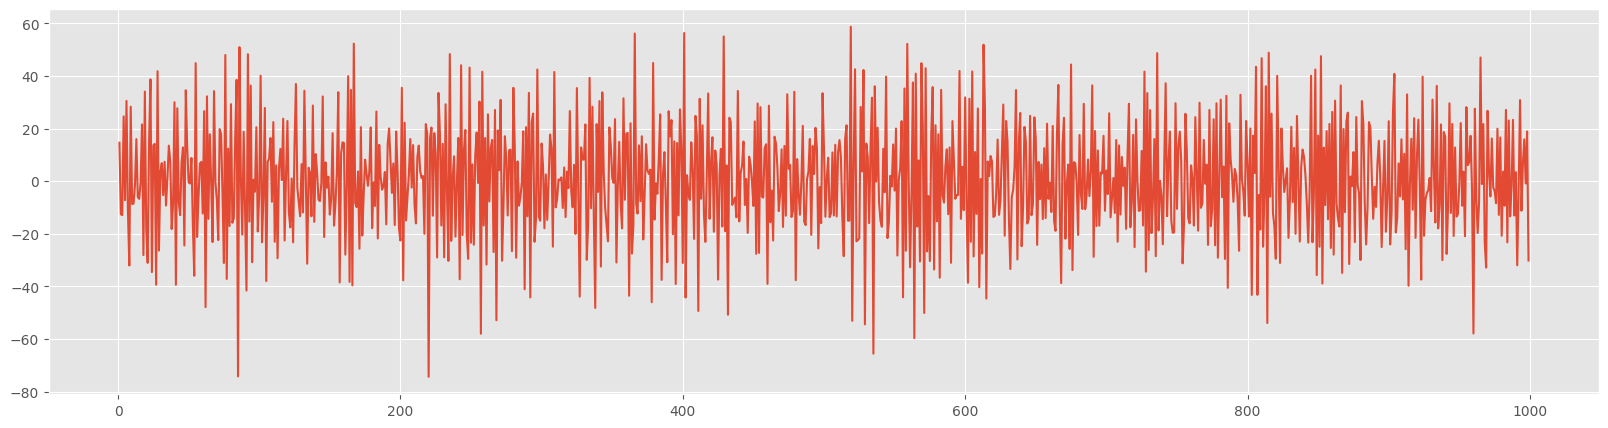

In [112]:
y_det.diff().dropna().plot()

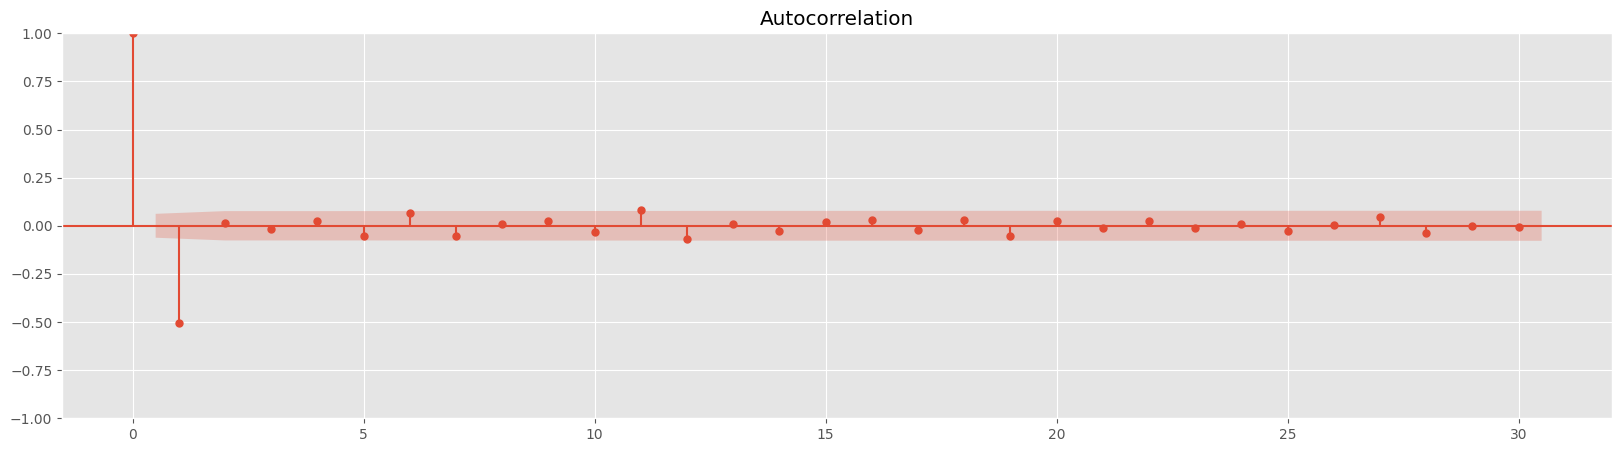

In [113]:
plot_acf(y_det.diff().dropna());

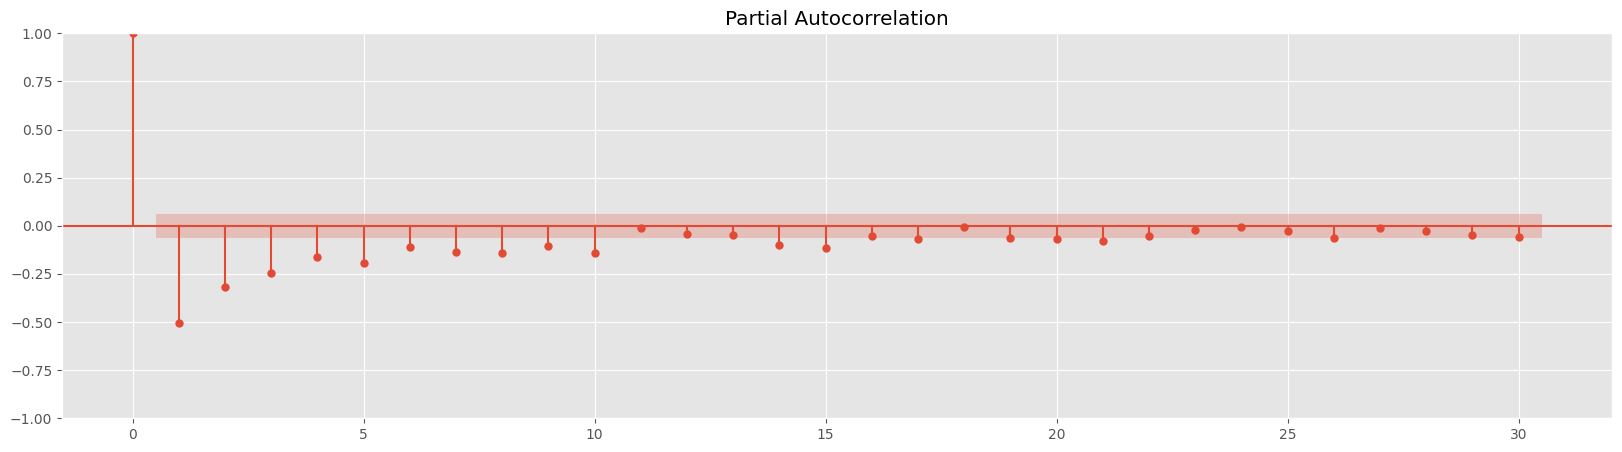

In [114]:
plot_pacf(y_det.diff().dropna());

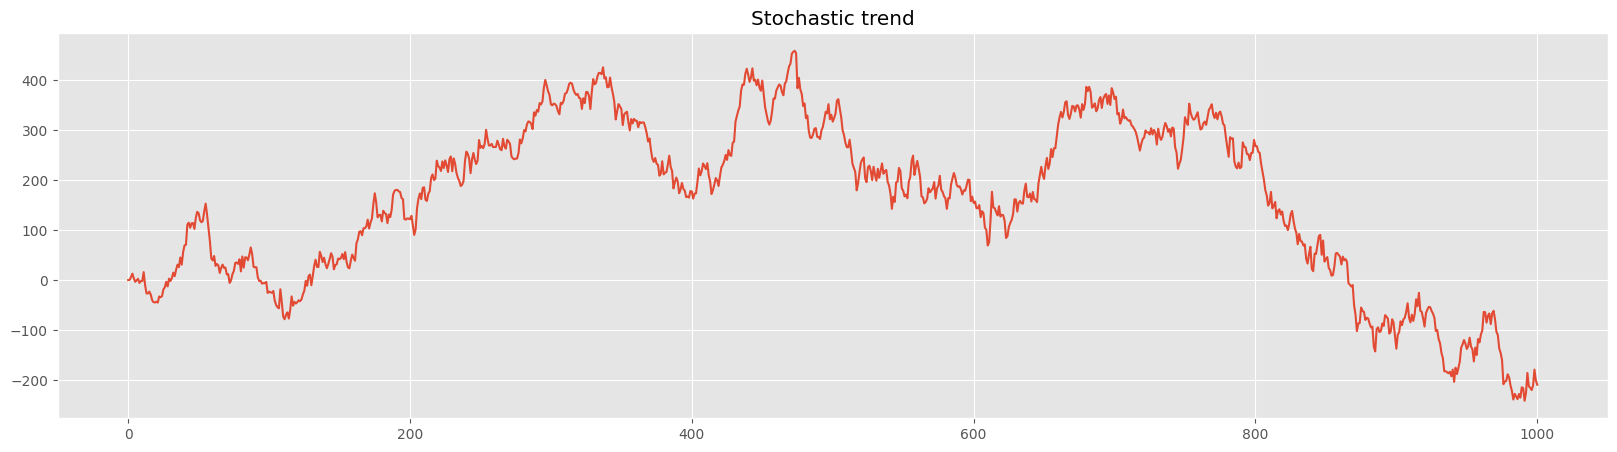

In [115]:
# Ряд со стохастическим трендом
y_stoch = [0]
[y_stoch.append(beta_0 + y_stoch[-1] + np.random.normal(scale=sigma_sq)) for t in range(n_steps)]

y_stoch = pd.Series(y_stoch)
y_stoch.plot()
plt.title("Stochastic trend");

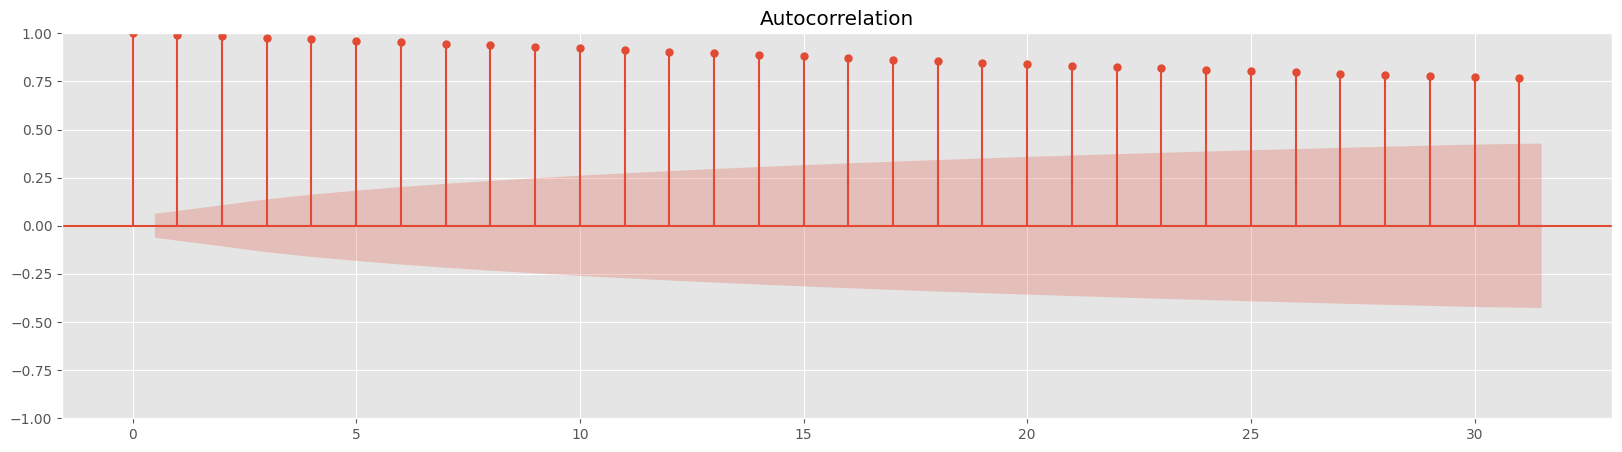

In [116]:
plot_acf(y_stoch);


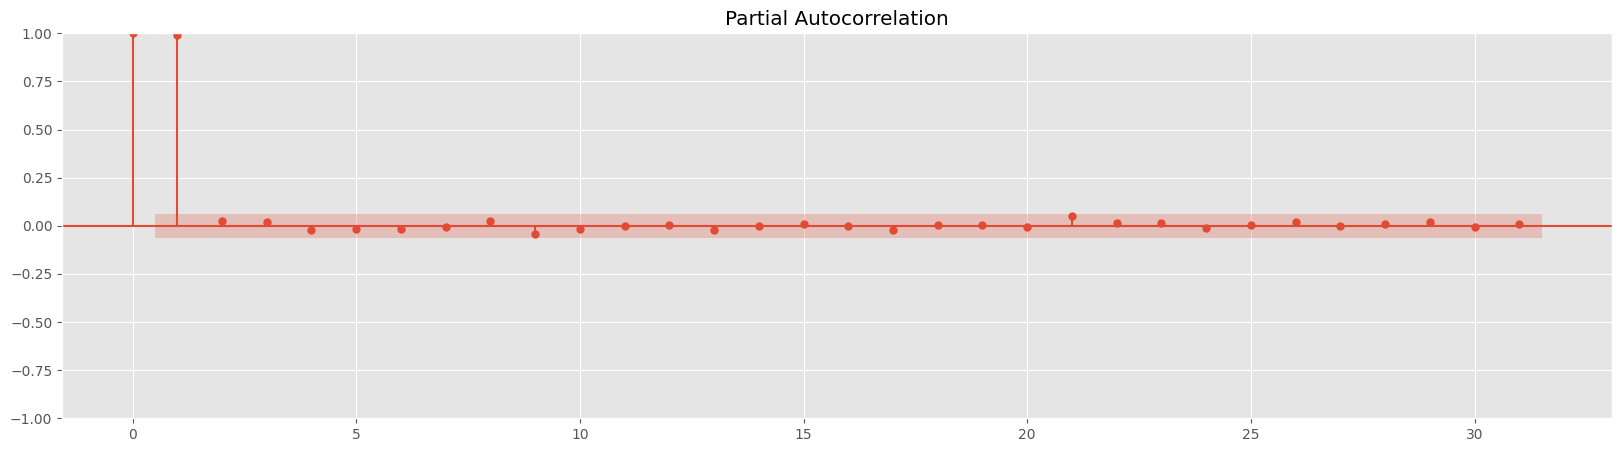

In [117]:
plot_pacf(y_stoch);


<Axes: >

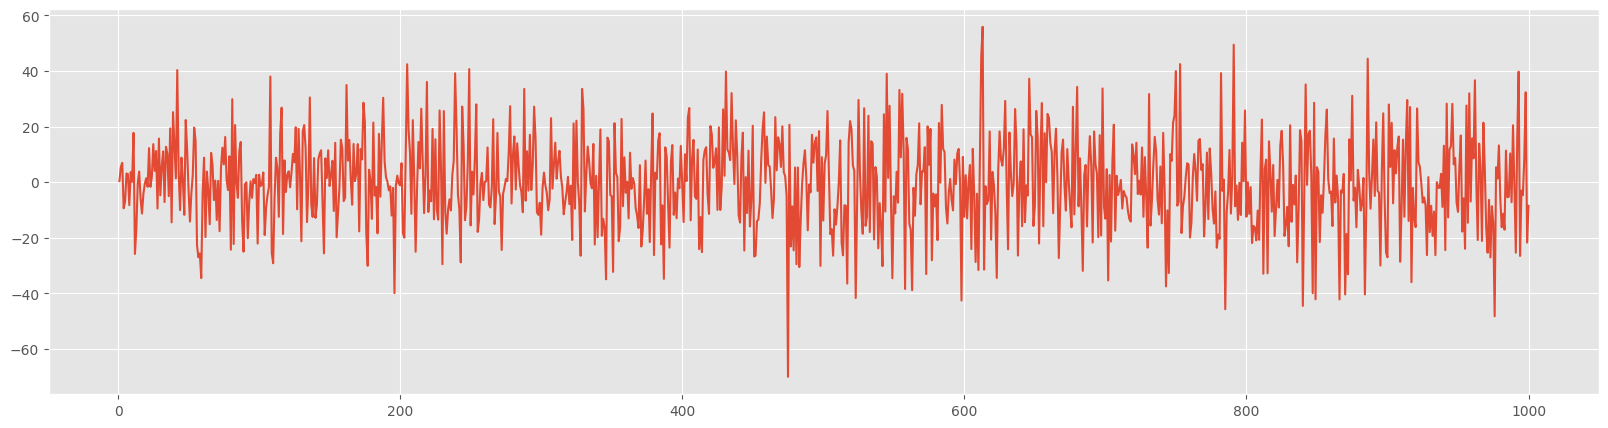

In [118]:
y_stoch.diff().dropna().plot()

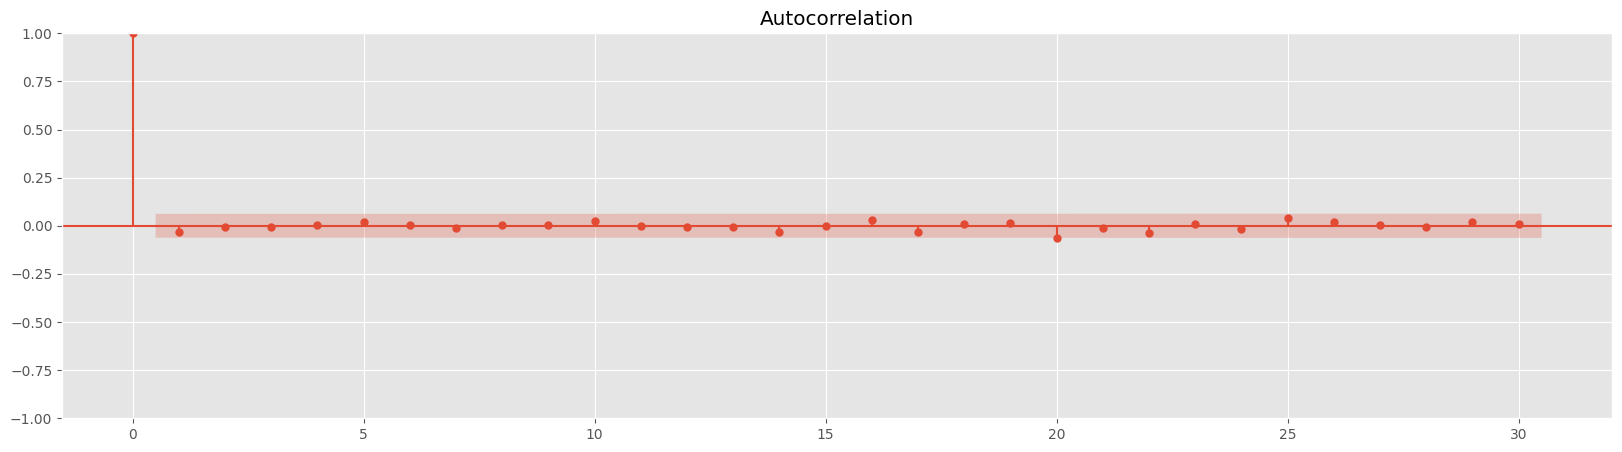

In [119]:
plot_acf(y_stoch.diff().dropna());

Теперь посмотрим на какие-нибудь нестационарные процессы и попытаемся оценить на них ARIMA-модель.

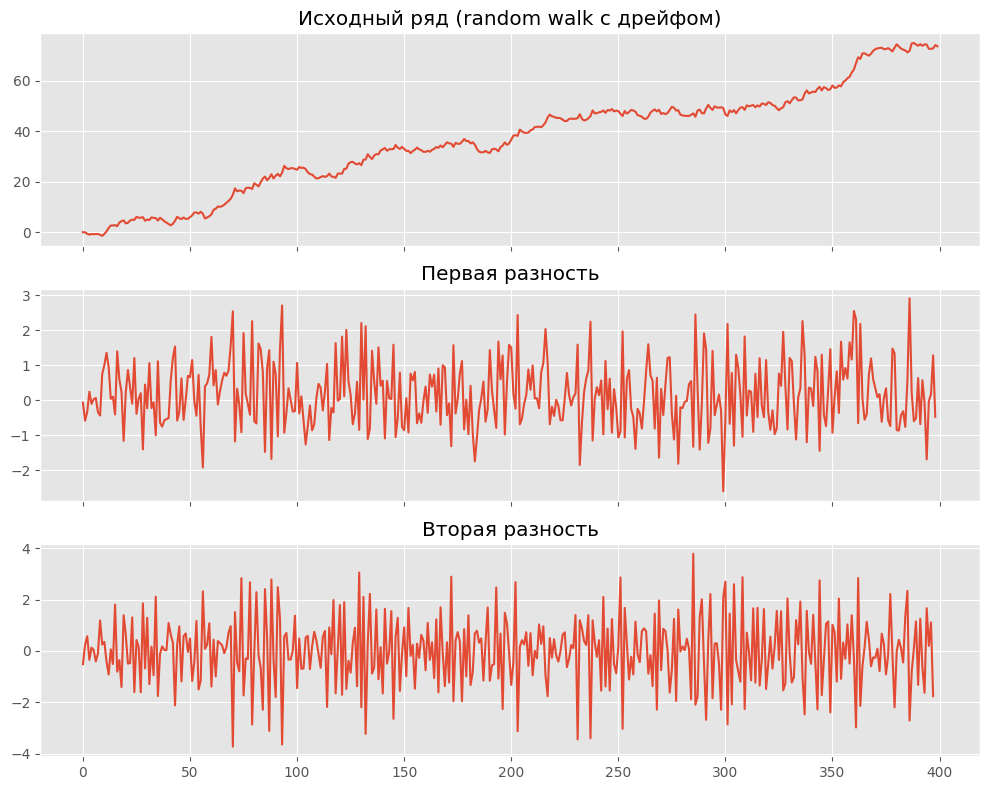

/Users/nalliennallien/anaconda3/envs/sheshkin/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


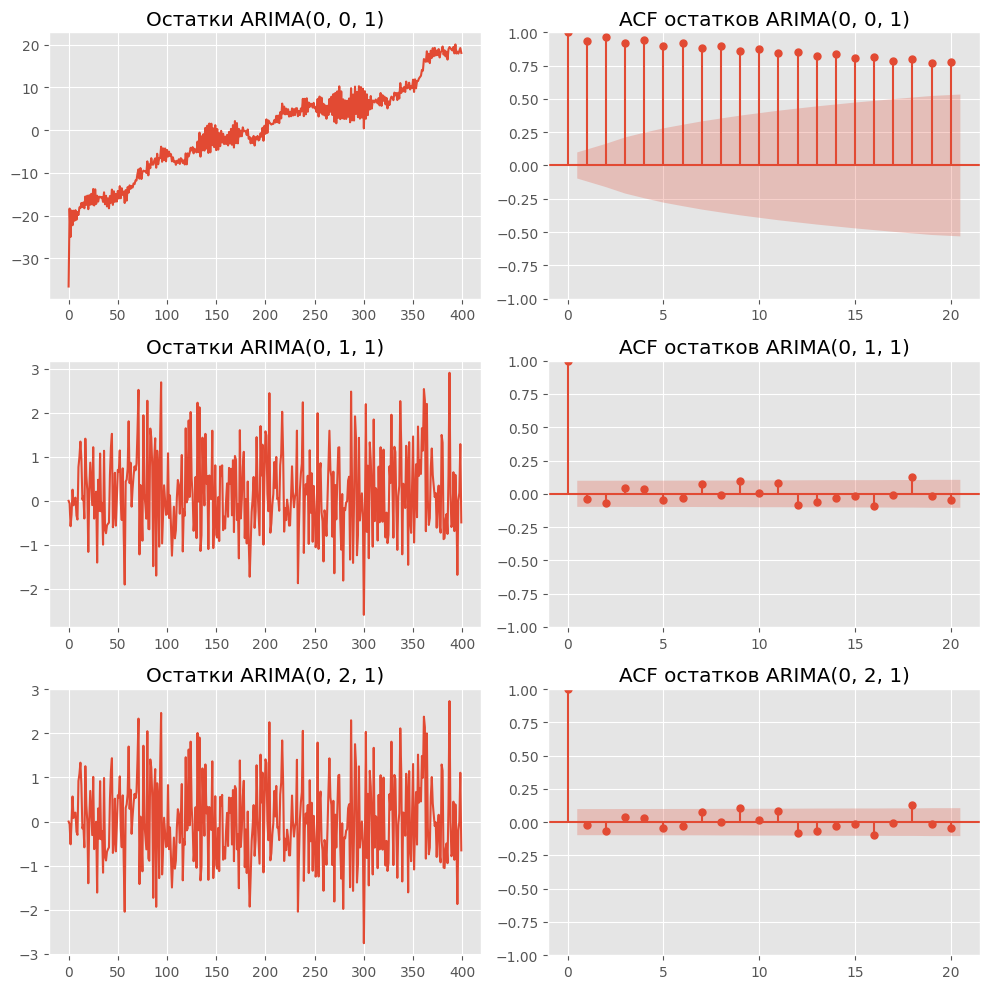

In [120]:
np.random.seed(322)

def random_walk_with_drift(n, mu=0.2, sigma=1.0):
    eps = np.random.normal(scale=sigma, size=n)
    y = np.zeros(n)
    for t in range(1, n):
        y[t] = mu + y[t - 1] + eps[t]
    return y

n = 400
y = random_walk_with_drift(n, mu=0.2, sigma=1.0)

fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax[0].plot(y)
ax[0].set_title('Исходный ряд (random walk с дрейфом)')

ax[1].plot(np.diff(y, n=1))
ax[1].set_title('Первая разность')

ax[2].plot(np.diff(y, n=2))
ax[2].set_title('Вторая разность')

plt.tight_layout()
plt.show()

def fit_arima_and_stats(y, order):
    model = ARIMA(y, order=order)
    res = model.fit()
    lb = acorr_ljungbox(res.resid, lags=[10], return_df=True)
    pvalue = lb['lb_pvalue'].iloc[0]
    return {
        'order': order,
        'aic': res.aic,
        'ljung_box_pvalue': pvalue,
        'resid': res.resid
    }

results = []
for order in [(0, 0, 1), (0, 1, 1), (0, 2, 1)]:
    stats = fit_arima_and_stats(y, order)
    results.append(stats)

summary_df = pd.DataFrame([
    {
        'order': r['order'],
        'AIC': r['aic'],
        'Ljung-Box pvalue': r['ljung_box_pvalue']
    }
    for r in results
])

fig, ax = plt.subplots(3, 2, figsize=(10, 10))

for i, r in enumerate(results):
    resid = r['resid']
    (p, d, q) = r['order']
    ax[i, 0].plot(resid)
    ax[i, 0].set_title(f'Остатки ARIMA{r["order"]}')
    plot_acf(resid, ax=ax[i, 1], lags=20)
    ax[i, 1].set_title(f'ACF остатков ARIMA{r["order"]}')

plt.tight_layout()
plt.show()

In [121]:
summary_df

,order,AIC,Ljung-Box pvalue
0,"(0, 0, 1)",3011.173499,0.000000
1,"(0, 1, 1)",1095.550990,0.319120
2,"(0, 2, 1)",1084.581427,0.326048


In [122]:
macro = sm.datasets.macrodata.load_pandas().data

y = macro['realgdp'].copy()
y.index = pd.date_range('1959-01-01', periods=len(y), freq='QS')

y = np.log(y)

test_horizon = 20
train = y.iloc[:-test_horizon]
test = y.iloc[-test_horizon:]

print(f'train length = {len(train)}, test length = {len(test)}')



train length = 183, test length = 20


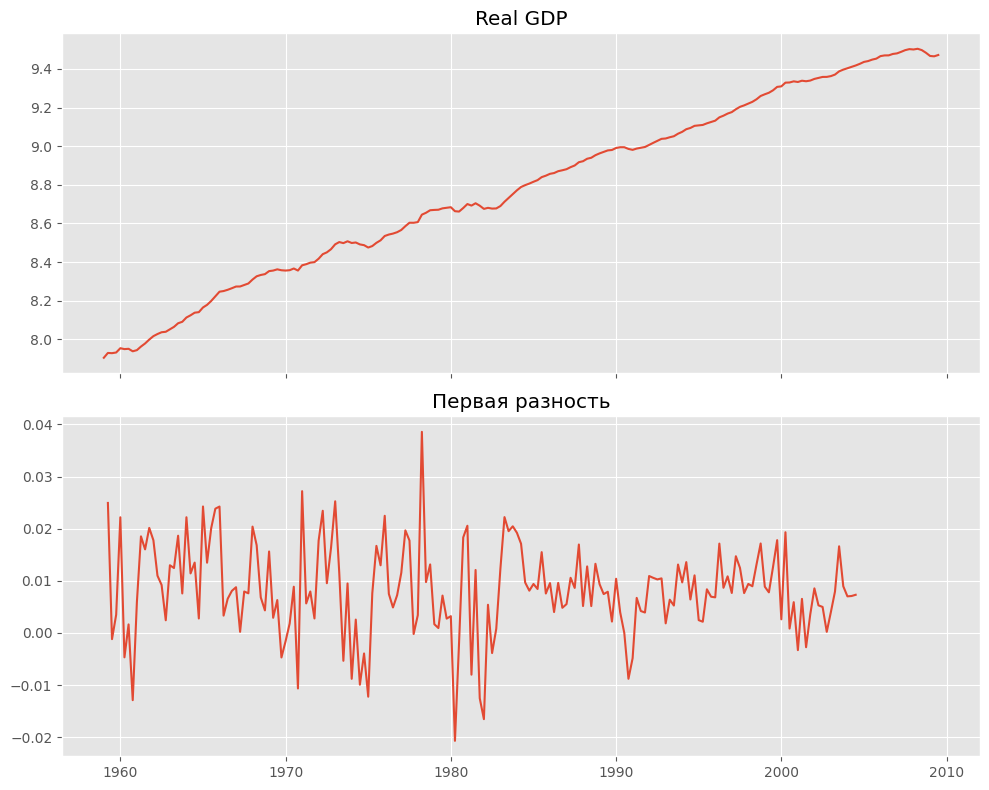

In [123]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax[0].plot(y)
ax[0].set_title('Real GDP')
diff1 = train.diff().dropna()
ax[1].plot(diff1)
ax[1].set_title('Первая разность')
plt.tight_layout()
plt.show()



In [124]:
model = ARIMA(train, order=(1, 1, 1))
res = model.fit()

print(res.summary())



                               SARIMAX Results                                
Dep. Variable:                realgdp   No. Observations:                  183
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 601.391
Date:                Fri, 27 Feb 2026   AIC                          -1196.782
Time:                        20:46:02   BIC                          -1187.170
Sample:                    01-01-1959   HQIC                         -1192.886
                         - 07-01-2004                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9198      0.040     23.166      0.000       0.842       0.998
ma.L1         -0.5519      0.083     -6.622      0.000      -0.715      -0.389
sigma2      7.857e-05   6.98e-06     11.257      0.0

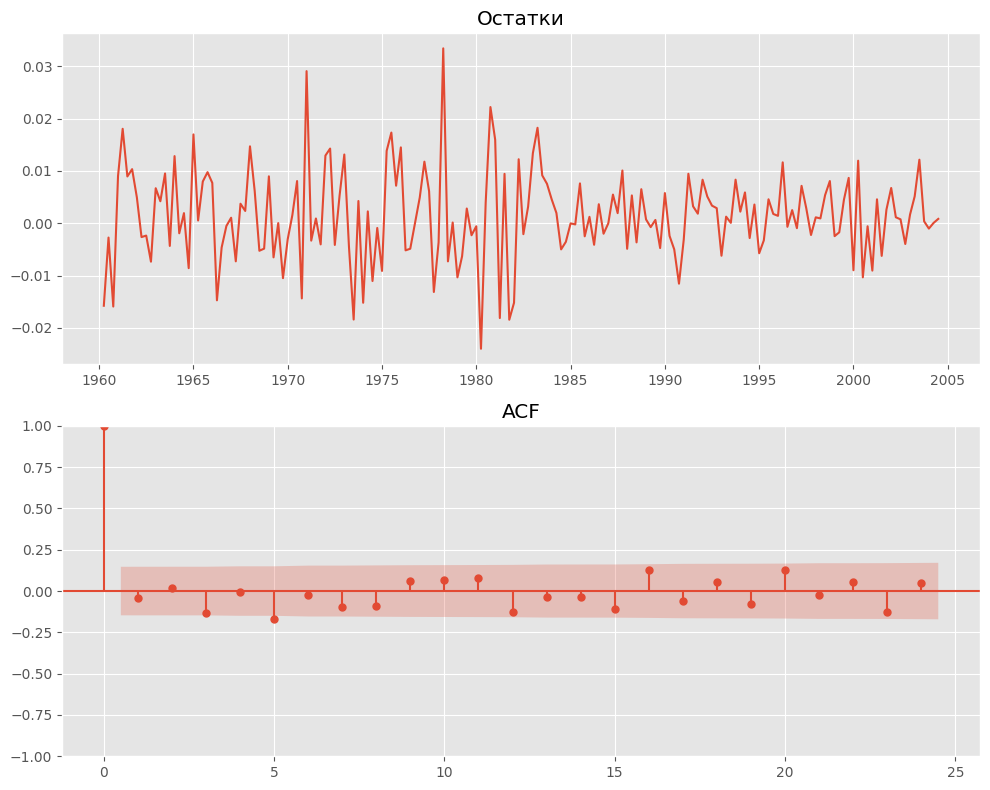

Ljung–Box test
      lb_stat  lb_pvalue
10  13.942622   0.175625
20  30.214335   0.066454


In [125]:
raw_resid = res.resid
resid = raw_resid[5:]
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

ax[0].plot(resid)
ax[0].set_title('Остатки')

plot_acf(resid, ax=ax[1], lags=24)
ax[1].set_title('ACF')

plt.tight_layout()
plt.show()

lb = acorr_ljungbox(resid, lags=[10, 20], return_df=True)
print('Ljung–Box test')
print(lb)


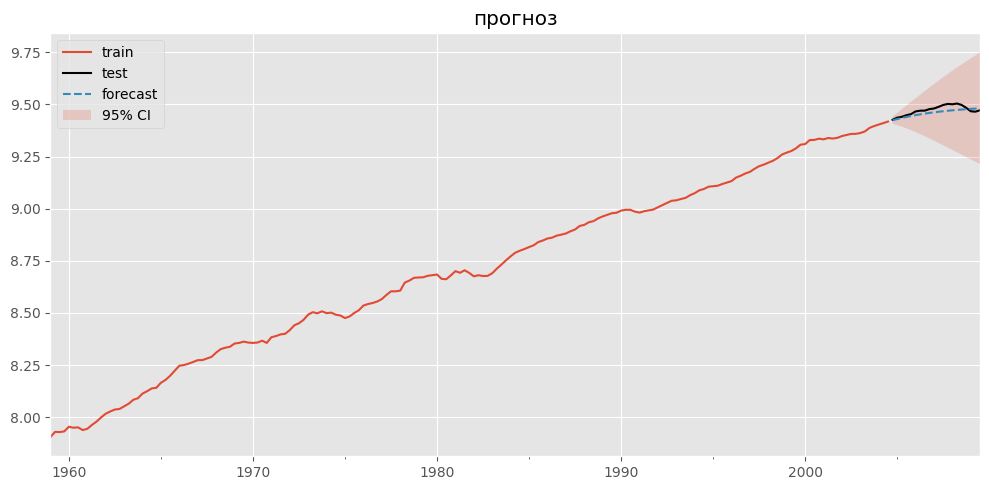

In [126]:
n_forecast = len(test)
forecast_res = res.get_forecast(steps=n_forecast)

pred_mean = forecast_res.predicted_mean
pred_ci = forecast_res.conf_int(alpha=0.05)

pred_mean.index = test.index
pred_ci.index = test.index

fig, ax = plt.subplots(figsize=(10, 5))

train.plot(ax=ax, label='train')
test.plot(ax=ax, label='test', color='black')

pred_mean.plot(ax=ax, label='forecast', linestyle='--')

ax.fill_between(
    pred_ci.index,
    pred_ci.iloc[:, 0],
    pred_ci.iloc[:, 1],
    alpha=0.2,
    label='95% CI'
)

ax.set_title('прогноз')
ax.legend()
plt.tight_layout()
plt.show()